# Price Driver Analysis



In [76]:
# Done By: Kedar Raju Pawar
# date:2026-02-24 time:time: 19:00:15

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Correlation Matrix

### Research Question


- Which product features significantly influence laptop pricing?

### Approach Used

- Test Used: Independent Samples T-Test
- Hypothesis Framework (For Correlation)


- H0: There is no linear relationship between feature X and price i.e x==y
- H1: There is a statistically significant relationship between feature X and price. i.e. x<>y

### Load & Inspect Data

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../02_Data_Management/04_Processed_Data/analytics_dataset.csv")
df.head()


,Company,laptop_type,screen_size_inch,display_resolution_width,display_resolution_height,panel_type,is_touchscreen,resolution_class,cpu_brand,cpu_family,...,ssd_gb,hdd_gb,flash_gb,hybrid_gb,total_storage_gb,weight_kg,weight_class,price_band,Price,is_price_outlier
0,APPLE,Ultrabook,13.3,2560,1600,IPS,No,Quad HD+,Intel,i5,...,128,0,0,0,128,1.37,Medium,Mid-Range,71378.6832,No
1,APPLE,Ultrabook,13.3,1440,900,Standard,No,HD+,Intel,i5,...,0,0,128,0,128,1.34,Medium,Mid-Range,47895.5232,No
2,HP,Notebook,15.6,1920,1080,Standard,No,Full HD,Intel,i5,...,256,0,0,0,256,1.86,Medium,Budget,30636.0000,No
3,APPLE,Ultrabook,15.4,2880,1800,IPS,No,Quad HD+,Intel,i7,...,512,0,0,0,512,1.83,Medium,Premium,135195.3360,Yes
4,APPLE,Ultrabook,13.3,2560,1600,IPS,No,Quad HD+,Intel,i5,...,256,0,0,0,256,1.37,Medium,Premium,96095.8080,No


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company                    1000 non-null   object 
 1   laptop_type                1000 non-null   object 
 2   screen_size_inch           1000 non-null   float64
 3   display_resolution_width   1000 non-null   int64  
 4   display_resolution_height  1000 non-null   int64  
 5   panel_type                 1000 non-null   object 
 6   is_touchscreen             1000 non-null   object 
 7   resolution_class           1000 non-null   object 
 8   cpu_brand                  1000 non-null   object 
 9   cpu_family                 1000 non-null   object 
 10  cpu_generation             821 non-null    float64
 11  clock_speed_ghz            1000 non-null   float64
 12  cpu_tier                   1000 non-null   object 
 13  gpu_brand                  1000 non-null   object

#### Clean & Encode Features

In [73]:
df["cpu_tier"].value_counts()
# CPU tier demonstrates the strongest monotonic relationship with price, reinforcing that processor performance is a 
# primary determinant of premium positioning.

cpu_tier
High         405
Upper-Mid    351
Mid          117
Entry        112
Lower-Mid     15
Name: count, dtype: int64

In [56]:
cpu_mapping = {
    "Entry": 1,
    "Lower-Mid": 2,
    "Mid": 3,
    "Upper-Mid": 4,
    "High": 5
}

df["cpu_tier_num"] = df["cpu_tier"].map(cpu_mapping)

df["cpu_tier_num"] = df["cpu_tier"].map(cpu_mapping)
df["cpu_tier_num"]
# Storage capacity shows comparatively weaker pricing sensitivity, suggesting baseline storage levels may be 
# standardized across tiers, reducing its marginal pricing power.

0      4
1      4
2      4
3      5
4      4
      ..
995    4
996    5
997    1
998    5
999    5
Name: cpu_tier_num, Length: 1000, dtype: int64

In [74]:
print(df["Price"].dtype)
print(df["Price"].isnull().sum())
print(df["Price"].describe())
print(df["Price"].skew())

float64
0
count      1000.00000
mean      59977.61941
std       37582.68151
min       10224.43200
25%       31914.72000
50%       51122.16000
75%       78548.04000
max      324954.72000
Name: Price, dtype: float64
1.620813266386072


#### Check Distribution of Price

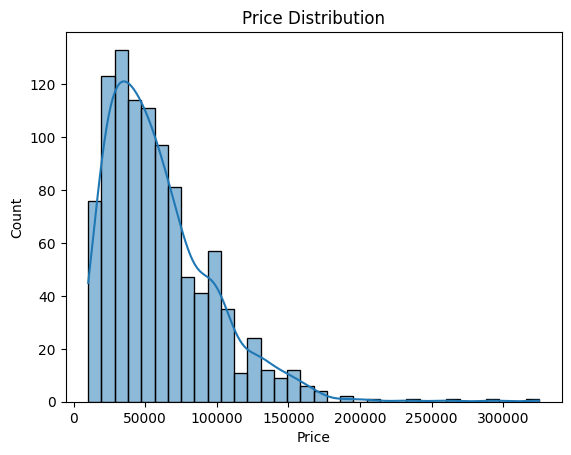

In [65]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

In [67]:
df["Price"].skew()

np.float64(1.620813266386072)

### Select Variables for Correlation

- Among tested features,Storage_gb tier exhibits the strongest association with price, followed by CPU tier and RAM, indicating performance architecture is the dominant pricing lever.

In [75]:
corr_df=df[[
        "Price",
        "ram_gb",
        "total_storage_gb",
        "cpu_tier_num",
]]

### compute the correlation

- IF pearson

In [70]:
corr_matrix=corr_df.corr(method="pearson")
corr_matrix

,Price,ram_gb,total_storage_gb,cpu_tier_num
Price,1.000000,0.763395,0.161358,0.611830
ram_gb,0.763395,1.000000,0.343290,0.546935
total_storage_gb,0.161358,0.343290,1.000000,0.264069
cpu_tier_num,0.611830,0.546935,0.264069,1.000000


- if spearman

In [71]:
corr_matrix=corr_df.corr(method="spearman")
corr_matrix

,Price,ram_gb,total_storage_gb,cpu_tier_num
Price,1.000000,0.777695,0.235696,0.761337
ram_gb,0.777695,1.000000,0.386082,0.732764
total_storage_gb,0.235696,0.386082,1.000000,0.371945
cpu_tier_num,0.761337,0.732764,0.371945,1.000000


### Visualize

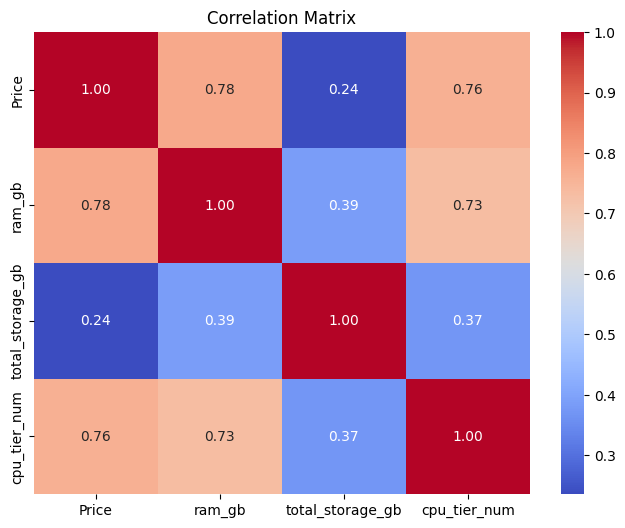

In [72]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()